The relationship is:        
Notebook (experiment)  →  src/model.py (production)

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import os
import yaml
import warnings
warnings.filterwarnings('ignore')

### Step 1: Load Engineered Splits

In [2]:
config_file = os.path.join("..","config","config.yaml")

with open(config_file,"r") as f:
    config = yaml.safe_load(f)

root_dir = os.path.dirname(os.path.dirname(os.path.abspath(config_file)))
engineered_path = os.path.join(root_dir,config["paths"]["engineered_data"])

print("The path of the engineered_data is: ",engineered_path)

The path of the engineered_data is:  c:\Users\DELL\Desktop\loan-risk-system\data/engineered_data/


In [3]:
X_train_cls_engineered = pd.read_csv(os.path.join(engineered_path,"X_train_cls_engineered.csv"))
X_test_cls_engineered = pd.read_csv(os.path.join(engineered_path,"X_test_cls_engineered.csv"))
X_val_cls_engineered = pd.read_csv(os.path.join(engineered_path,"X_val_cls_engineered.csv"))
y_train_cls_engineered = pd.read_csv(os.path.join(engineered_path,"y_train_cls_engineered.csv"))
y_test_cls_engineered = pd.read_csv(os.path.join(engineered_path,"y_test_cls_engineered.csv"))
y_val_cls_engineered = pd.read_csv(os.path.join(engineered_path,"y_val_cls_engineered.csv"))

print("X_train_cls_engineered shape is: ",X_train_cls_engineered.shape)
print("X_test_cls_engineered shape is: ",X_test_cls_engineered.shape)
print("X_val_cls_engineered shape is: ",X_val_cls_engineered.shape)
print("y_train_cls_engineered shape is: ",y_train_cls_engineered.shape)
print("y_test_cls_engineered shape is: ",y_test_cls_engineered.shape)
print("y_val_cls_engineered shape is: ",y_val_cls_engineered.shape)

print("All Classification Engineered Dataset Fully Loaded...")

X_train_cls_engineered shape is:  (27577, 23)
X_test_cls_engineered shape is:  (2444, 23)
X_val_cls_engineered shape is:  (2444, 23)
y_train_cls_engineered shape is:  (27577, 1)
y_test_cls_engineered shape is:  (2444, 1)
y_val_cls_engineered shape is:  (2444, 1)
All Classification Engineered Dataset Fully Loaded...


In [4]:
X_train_reg_engineered = pd.read_csv(os.path.join(engineered_path,"X_train_reg_engineered.csv"))
X_test_reg_engineered = pd.read_csv(os.path.join(engineered_path,"X_test_reg_engineered.csv"))
X_val_reg_engineered = pd.read_csv(os.path.join(engineered_path,"X_val_reg_engineered.csv"))
y_train_reg_engineered = pd.read_csv(os.path.join(engineered_path,"y_train_reg_engineered.csv"))
y_test_reg_engineered = pd.read_csv(os.path.join(engineered_path,"y_test_reg_engineered.csv"))
y_val_reg_engineered = pd.read_csv(os.path.join(engineered_path,"y_val_reg_engineered.csv"))

print("X_train_reg_engineered shape is: ",X_train_reg_engineered.shape)
print("X_test_reg_engineered shape is: ",X_test_reg_engineered.shape)
print("X_val_reg_engineered shape is: ",X_val_reg_engineered.shape)
print("y_train_reg_engineered shape is: ",y_train_reg_engineered.shape)
print("y_test_reg_engineered shape is: ",y_test_reg_engineered.shape)
print("y_val_reg_engineered shape is: ",y_val_reg_engineered.shape)

print("All Regression Engineered Dataset Fully Loaded...")

X_train_reg_engineered shape is:  (24943, 16)
X_test_reg_engineered shape is:  (2210, 16)
X_val_reg_engineered shape is:  (2210, 16)
y_train_reg_engineered shape is:  (24943, 1)
y_test_reg_engineered shape is:  (2210, 1)
y_val_reg_engineered shape is:  (2210, 1)
All Regression Engineered Dataset Fully Loaded...


### Step 2 — Define Models: Classification

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

load_path = "../models/class_weights.pkl"
class_weight_dict = joblib.load(load_path)

# Classification models
# All use class_weight to handle imbalance

cls_models = {
    'LogisticRegression': LogisticRegression(
        class_weight=class_weight_dict,
        random_state=42,
        max_iter=1000),

    'RandomForest': RandomForestClassifier(
        class_weight=class_weight_dict,
        random_state=42,
        n_jobs=-1),

    'XGBoost': XGBClassifier(
        scale_pos_weight=2.28,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1),

    'LightGBM': LGBMClassifier(
        class_weight=class_weight_dict,
        random_state=42,
        n_jobs=-1,
        verbose=-1)
}

print("Classification models defined:")
for name in cls_models:
    print(f"  - {name}")

Classification models defined:
  - LogisticRegression
  - RandomForest
  - XGBoost
  - LightGBM


### Step 3: Define Models: Regression

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Regression models
reg_models = {
    'LinearRegression': LinearRegression(
        n_jobs=-1),

    'RandomForest': RandomForestRegressor(
        random_state=42,
        n_jobs=-1),

    'XGBoost': XGBRegressor(
        random_state=42,
        n_jobs=-1),

    'LightGBM': LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1)
}

print("Regression models defined:")
for name in reg_models:
    print(f"  - {name}")

Regression models defined:
  - LinearRegression
  - RandomForest
  - XGBoost
  - LightGBM


###  Step 4: Define Models: Clustering

In [7]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Clustering models
# n_clusters=3 for now — will find optimal in Step 9

cluster_models = {
    'KMeans': KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10),

    'GaussianMixture': GaussianMixture(
        n_components=3,
        random_state=42),

    'Hierarchical': AgglomerativeClustering(
        n_clusters=3,
        linkage='ward')
}

print("Clustering models defined:")
for name in cluster_models:
    print(f"  - {name}")

Clustering models defined:
  - KMeans
  - GaussianMixture
  - Hierarchical


###  Step 5: Cross Validation: Classification

Cross-validation is a robust resampling technique used to evaluate machine learning models by partitioning data into multiple subsets (folds), training on some, and validating on others iteratively. This process ensures every data point validates the model, reducing overfitting and providing a more accurate, generalized performance estimate than a single train/test split.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Stratified KFold — Its a variane of K-fold that preserves class distribution means each subset contain equal amoount of classes (0 and 1) --> Cls only
# 5 folds — industry standard0

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cls_cv_results = {}
for name, model in cls_models.items():
    print(f"Cross validating {name}...")
    
    start = time.time()
    
    cv_scores = cross_validate(
        model,
        X_train_cls_engineered,
        y_train_cls_engineered.values.ravel(),
        cv=cv,
        scoring=['accuracy', 'f1', 'roc_auc'],
        n_jobs=-1
    )
    
    cls_cv_results[name] = {
        'accuracy_mean':  cv_scores['test_accuracy'].mean().round(4),
        'accuracy_std':   cv_scores['test_accuracy'].std().round(4),
        'f1_mean':        cv_scores['test_f1'].mean().round(4),
        'f1_std':         cv_scores['test_f1'].std().round(4),
        'roc_auc_mean':   cv_scores['test_roc_auc'].mean().round(4),
        'roc_auc_std':    cv_scores['test_roc_auc'].std().round(4),
        'time':           round(time.time() - start, 2)
    }
    
    print(f"  F1: {cls_cv_results[name]['f1_mean']} "
          f"± {cls_cv_results[name]['f1_std']}")

print("\nClassification CV complete")
pd.DataFrame(cls_cv_results).T

Cross validating LogisticRegression...
  F1: 0.6151 ± 0.0104
Cross validating RandomForest...
  F1: 0.8077 ± 0.0072
Cross validating XGBoost...
  F1: 0.8237 ± 0.0077
Cross validating LightGBM...
  F1: 0.81 ± 0.0085

Classification CV complete


,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,time
LogisticRegression,0.7875,0.0071,0.6151,0.0104,0.8630,0.0050,0.54
RandomForest,0.9277,0.0025,0.8077,0.0072,0.9308,0.0039,14.98
XGBoost,0.9282,0.0032,0.8237,0.0077,0.9425,0.0032,1.55
LightGBM,0.9195,0.0036,0.8100,0.0085,0.9438,0.0033,1.62


### Step 6: Cross Validation: Regression

In [12]:
from sklearn.model_selection import KFold

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

reg_cv_results = {}
for name, model in reg_models.items():
    print(f"Cross validating {name}...")
    
    start = time.time()
    
    cv_scores = cross_validate(
        model,
        X_train_reg_engineered,
        y_train_reg_engineered.values.ravel(),
        cv=cv_reg,
        scoring=['r2','neg_root_mean_squared_error','neg_mean_absolute_error'],
        n_jobs=-1
    )
    
    reg_cv_results[name] = {
        'r2_mean':    cv_scores['test_r2'].mean().round(4),
        'r2_std':     cv_scores['test_r2'].std().round(4),
        'rmse_mean':  (-cv_scores['test_neg_root_mean_squared_error'].mean()).round(4),
        'rmse_std':   cv_scores['test_neg_root_mean_squared_error'].std().round(4),
        'mae_mean':   (-cv_scores['test_neg_mean_absolute_error'].mean()).round(4),
        'mae_std':    cv_scores['test_neg_mean_absolute_error'].std().round(4),
        'time':       round(time.time() - start, 2)
    }
    
    print(f"  R2: {reg_cv_results[name]['r2_mean']} "
          f"± {reg_cv_results[name]['r2_std']}")

print("\nRegression CV complete")
pd.DataFrame(reg_cv_results).T

Cross validating LinearRegression...
  R2: 0.8757 ± 0.0026
Cross validating RandomForest...
  R2: 0.9058 ± 0.0026
Cross validating XGBoost...
  R2: 0.9014 ± 0.0024
Cross validating LightGBM...
  R2: 0.905 ± 0.0022

Regression CV complete


,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std,time
LinearRegression,0.8757,0.0026,1.1394,0.0112,0.8913,0.0079,0.18
RandomForest,0.9058,0.0026,0.9920,0.0121,0.7596,0.0082,108.80
XGBoost,0.9014,0.0024,1.0147,0.0104,0.7926,0.0080,1.34
LightGBM,0.9050,0.0022,0.9960,0.0099,0.7825,0.0073,0.85


### Step 7: Hyperparameter Tuning: Classification

In [14]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import cross_val_score


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_rf_cls(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 300),
        'max_depth':         trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight':      class_weight_dict,
        'random_state':      42,
        'n_jobs':            -1
    }
    model = RandomForestClassifier(**params)
    score = cross_val_score(
        model,
        X_train_cls_engineered,
        y_train_cls_engineered.values.ravel(),
        cv=cv, 
        scoring='f1', 
        n_jobs=-1).mean()
    return score


def objective_xgb_cls(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 300),
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample':         trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'scale_pos_weight':  2.28,
        'random_state':      42,
        'n_jobs':            -1,
        'eval_metric':       'logloss'
    }
    model = XGBClassifier(**params)
    score = cross_val_score(
        model,
        X_train_cls_engineered,
        y_train_cls_engineered.values.ravel(),
        cv=cv, scoring='f1', n_jobs=-1).mean()
    return score


def objective_lgbm_cls(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 300),
        'max_depth':     trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves':    trial.suggest_int('num_leaves', 31, 100),
        'subsample':     trial.suggest_float('subsample', 0.7, 1.0),
        'class_weight':  class_weight_dict,
        'random_state':  42,
        'n_jobs':        -1,
        'verbose':       -1
    }
    model = LGBMClassifier(**params)
    score = cross_val_score(
        model,
        X_train_cls_engineered,
        y_train_cls_engineered.values.ravel(),
        cv=cv, scoring='f1', n_jobs=-1).mean()
    return score


# Run studies
cls_best_params = {}

for name, objective in [
    ('RandomForest', objective_rf_cls),
    ('XGBoost',      objective_xgb_cls),
    ('LightGBM',     objective_lgbm_cls)
]:
    print(f"Tuning {name}...")
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=True)
    cls_best_params[name] = study.best_params
    print(f"  Best F1: {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}\n")

print("Classification tuning complete")

Tuning RandomForest...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best F1: 0.8079
  Best params: {'n_estimators': 299, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2'}

Tuning XGBoost...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best F1: 0.8324
  Best params: {'n_estimators': 213, 'max_depth': 7, 'learning_rate': 0.12358921464824361, 'subsample': 0.9322809142547737, 'colsample_bytree': 0.8786846811421739}

Tuning LightGBM...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best F1: 0.8277
  Best params: {'n_estimators': 235, 'max_depth': 7, 'learning_rate': 0.1745169142357489, 'num_leaves': 54, 'subsample': 0.8596985276023658}

Classification tuning complete


### Step 8: Hyperparameter Tuning: Regression

In [15]:
from sklearn.model_selection import cross_val_score

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

def objective_rf_reg(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 300),
        'max_depth':         trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state':      42,
        'n_jobs':            -1
    }
    model = RandomForestRegressor(**params)
    score = cross_val_score(
        model,
        X_train_reg_engineered,
        y_train_reg_engineered.values.ravel(),
        cv=cv_reg, scoring='r2', n_jobs=-1).mean()
    return score


def objective_xgb_reg(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 300),
        'max_depth':        trial.suggest_int('max_depth', 3, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample':        trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'random_state':     42,
        'n_jobs':           -1
    }
    model = XGBRegressor(**params)
    score = cross_val_score(
        model,
        X_train_reg_engineered,
        y_train_reg_engineered.values.ravel(),
        cv=cv_reg, scoring='r2', n_jobs=-1).mean()
    return score


def objective_lgbm_reg(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 300),
        'max_depth':     trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves':    trial.suggest_int('num_leaves', 31, 100),
        'subsample':     trial.suggest_float('subsample', 0.7, 1.0),
        'random_state':  42,
        'n_jobs':        -1,
        'verbose':       -1
    }
    model = LGBMRegressor(**params)
    score = cross_val_score(
        model,
        X_train_reg_engineered,
        y_train_reg_engineered.values.ravel(),
        cv=cv_reg, scoring='r2', n_jobs=-1).mean()
    return score


reg_best_params = {}
for name, objective in [
    ('RandomForest', objective_rf_reg),
    ('XGBoost',      objective_xgb_reg),
    ('LightGBM',     objective_lgbm_reg)
]:
    print(f"Tuning {name}...")
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=True)
    reg_best_params[name] = study.best_params
    print(f"  Best R2: {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}\n")

print("Regression tuning complete")

Tuning RandomForest...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best R2: 0.9061
  Best params: {'n_estimators': 205, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

Tuning XGBoost...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best R2: 0.9054
  Best params: {'n_estimators': 176, 'max_depth': 7, 'learning_rate': 0.037063929310718925, 'subsample': 0.7437922067606186, 'colsample_bytree': 0.8350746997147329}

Tuning LightGBM...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best R2: 0.9049
  Best params: {'n_estimators': 146, 'max_depth': 6, 'learning_rate': 0.05851144157636089, 'num_leaves': 73, 'subsample': 0.7232192344691581}

Regression tuning complete


### Step 9: Find Optimal K: Clustering

In [31]:
from sklearn.metrics import silhouette_score

# Test k from 2 to 10
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    print(f"Testing k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_cls_engineered)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(
        X_train_cls_engineered, labels))

print("Optimal k search complete")

Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...
Testing k=7...
Testing k=8...
Testing k=9...
Testing k=10...
Optimal k search complete


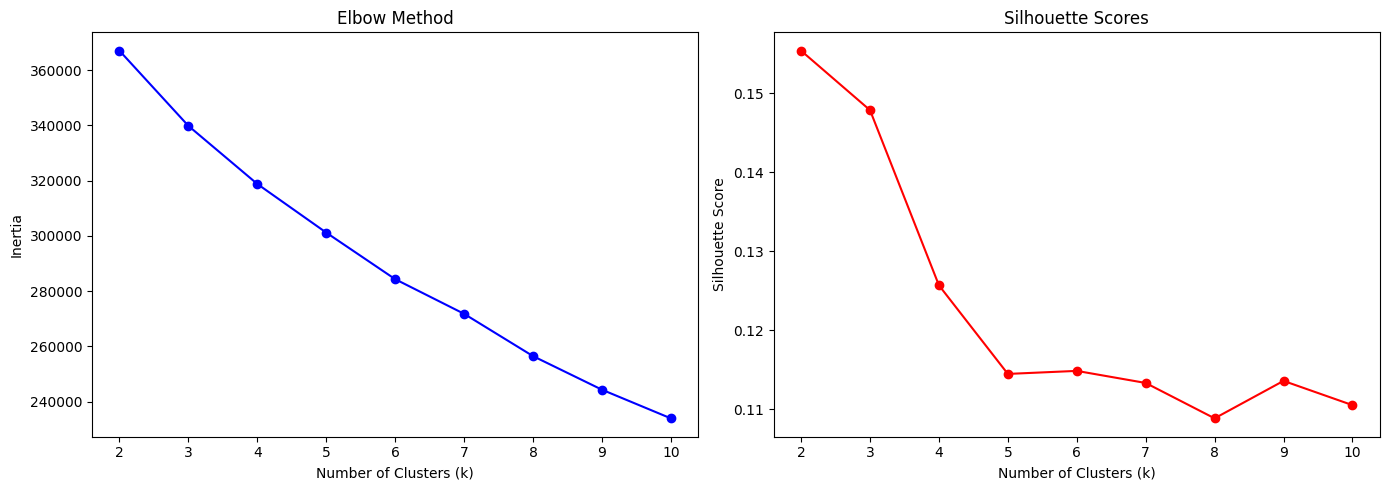

Best k by silhouette: 2
Best silhouette score: 0.1554


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

# Silhouette plot
axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores')

plt.tight_layout()
plt.show()

# Print best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best k by silhouette: {best_k}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")

### Step 10: Hyperparameter Tuning: Clustering

In [21]:
# Clustering

def objective_kmeans(trial):
    params = {
        'n_clusters': trial.suggest_int('n_clusters', 2, 6),
        'init':       trial.suggest_categorical('init', ['k-means++', 'random']),
        'n_init':     trial.suggest_int('n_init', 10, 30),
        'random_state': 42
    }
    model = KMeans(**params)
    labels = model.fit_predict(X_train_cls_engineered)
    score = silhouette_score(X_train_cls_engineered, labels)
    return score


def objective_gmm(trial):
    params = {
        'n_components':  trial.suggest_int('n_components', 2, 6),
        'covariance_type': trial.suggest_categorical(
            'covariance_type', ['full', 'tied', 'diag', 'spherical']),
        'random_state':  42
    }
    model = GaussianMixture(**params)
    labels = model.fit_predict(X_train_cls_engineered)
    score = silhouette_score(X_train_cls_engineered, labels)
    return score


def objective_hierarchical(trial):
    params = {
        'n_clusters': trial.suggest_int('n_clusters', 2, 6),
        'linkage':    trial.suggest_categorical(
            'linkage', ['ward', 'complete', 'average'])
    }
    model = AgglomerativeClustering(**params)
    labels = model.fit_predict(X_train_cls_engineered)
    score = silhouette_score(X_train_cls_engineered, labels)
    return score


cluster_best_params = {}
for name, objective in [
    ('KMeans',      objective_kmeans),
    ('GMM',         objective_gmm),
    ('Hierarchical', objective_hierarchical)
]:
    print(f"Tuning {name}...")
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=True)
    cluster_best_params[name] = study.best_params
    print(f"  Best Silhouette: {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}\n")

print("Clustering tuning complete")

Tuning KMeans...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best Silhouette: 0.1551
  Best params: {'n_clusters': 2, 'init': 'random', 'n_init': 30}

Tuning GMM...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best Silhouette: 0.1914
  Best params: {'n_components': 2, 'covariance_type': 'full'}

Tuning Hierarchical...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best Silhouette: 0.9628
  Best params: {'n_clusters': 2, 'linkage': 'complete'}

Clustering tuning complete


In [62]:
cluster_best_params

{'KMeans': {'n_clusters': 2, 'init': 'random', 'n_init': 30},
 'GMM': {'n_components': 2, 'covariance_type': 'spherical'},
 'Hierarchical': {'n_clusters': 3, 'linkage': 'ward'}}

In [22]:
# Check hierarchical clusters
model = AgglomerativeClustering(n_clusters=2, linkage='average')
labels = model.fit_predict(X_train_cls_engineered)

# Check cluster sizes
unique, counts = np.unique(labels, return_counts=True)
print("Cluster sizes:")
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples")

Cluster sizes:
  Cluster 0: 27576 samples
  Cluster 1: 1 samples


In [23]:
# Override hierarchical best params
cluster_best_params['Hierarchical'] = {
    'n_clusters': 3,
    'linkage': 'ward'
}

# Verify
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X_train_cls_engineered)

unique, counts = np.unique(labels, return_counts=True)
print("Cluster sizes:")
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples")

score = silhouette_score(X_train_cls_engineered, labels)
print(f"Real silhouette: {score:.4f}")

Cluster sizes:
  Cluster 0: 4372 samples
  Cluster 1: 2699 samples
  Cluster 2: 20506 samples
Real silhouette: 0.1553


In [33]:
cluster_best_params['KMeans']['n_clusters'] = 2
cluster_best_params['Hierarchical']['n_clusters'] = 3
cluster_best_params['GMM']['n_components'] = 2
cluster_best_params['GMM']['covariance_type'] = 'spherical'


print(cluster_best_params)

{'KMeans': {'n_clusters': 2, 'init': 'random', 'n_init': 30}, 'GMM': {'n_components': 2, 'covariance_type': 'spherical'}, 'Hierarchical': {'n_clusters': 3, 'linkage': 'ward'}}


### Step 11: Train Final Models: Classification

In [25]:
# Train final classification models with best params
# Use full training data

final_cls_models = {}
for name, params in cls_best_params.items():
    print(f"Training {name}...")
    start = time.time()
    
    if name == 'RandomForest':
        model = RandomForestClassifier(
            **params,
            class_weight=class_weight_dict,
            random_state=42,
            n_jobs=-1)
    
    elif name == 'XGBoost':
        model = XGBClassifier(
            **params,
            scale_pos_weight=2.28,
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss')
    
    elif name == 'LightGBM':
        model = LGBMClassifier(
            **params,
            class_weight=class_weight_dict,
            random_state=42,
            n_jobs=-1,
            verbose=-1)
    
    # Train on full training data
    model.fit(X_train_cls_engineered,
              y_train_cls_engineered.values.ravel())
    
    final_cls_models[name] = model
    print(f"Done in {round(time.time()-start, 2)}s")

# Also train LogisticRegression with default params
print("Training LogisticRegression...")
lr = LogisticRegression(
    class_weight=class_weight_dict,
    random_state=42,
    max_iter=1000)
lr.fit(X_train_cls_engineered,
       y_train_cls_engineered.values.ravel())
final_cls_models['LogisticRegression'] = lr
print("Done")

print(f"\nAll classification models trained")
print(f"Total models: {len(final_cls_models)}")

Training RandomForest...
Done in 8.54s
Training XGBoost...
Done in 1.64s
Training LightGBM...
Done in 1.32s
Training LogisticRegression...
Done

All classification models trained
Total models: 4


###  Step 12: Train Final Models: Regression

In [26]:
final_reg_models = {}

for name, params in reg_best_params.items():
    print(f"Training {name}...")
    start = time.time()
    
    if name == 'RandomForest':
        model = RandomForestRegressor(
            **params,
            random_state=42,
            n_jobs=-1)
    
    elif name == 'XGBoost':
        model = XGBRegressor(
            **params,
            random_state=42,
            n_jobs=-1)
    
    elif name == 'LightGBM':
        model = LGBMRegressor(
            **params,
            random_state=42,
            n_jobs=-1,
            verbose=-1)
    
    model.fit(X_train_reg_engineered,
              y_train_reg_engineered.values.ravel())
    
    final_reg_models[name] = model
    print(f"Done in {round(time.time()-start, 2)}s")

# Also train LinearRegression
print("Training LinearRegression...")
lr_reg = LinearRegression(n_jobs=-1)
lr_reg.fit(X_train_reg_engineered,
           y_train_reg_engineered.values.ravel())
final_reg_models['LinearRegression'] = lr_reg
print("Done")

print(f"\nAll regression models trained")
print(f"Total models: {len(final_reg_models)}")

Training RandomForest...
Done in 8.19s
Training XGBoost...
Done in 1.47s
Training LightGBM...
Done in 0.68s
Training LinearRegression...
Done

All regression models trained
Total models: 4


###  Step 13: Train Final Models: Clustering

In [34]:
final_cluster_models = {}

for name, params in cluster_best_params.items():
    print(f"Training {name}...")
    start = time.time()
    
    if name == 'KMeans':
        model = KMeans(**params, random_state=42)
    
    elif name == 'GMM':
        model = GaussianMixture(**params, random_state=42)
    
    elif name == 'Hierarchical':
        model = AgglomerativeClustering(**params)
    
    # Fit model
    model.fit(X_train_cls_engineered)
    
    # Get labels
    if name == 'GMM':
        labels = model.predict(X_train_cls_engineered)
    else:
        labels = model.fit_predict(X_train_cls_engineered)
    
    # Evaluate
    score = silhouette_score(X_train_cls_engineered, labels)
    
    final_cluster_models[name] = model
    print(f"  Silhouette: {score:.4f}")
    print(f"Done in {round(time.time()-start, 2)}s")

print(f"\nAll clustering models trained")
print(f"Total models: {len(final_cluster_models)}")

Training KMeans...
  Silhouette: 0.1551
Done in 14.57s
Training GMM...
  Silhouette: 0.2332
Done in 11.41s
Training Hierarchical...
  Silhouette: 0.1553
Done in 109.67s

All clustering models trained
Total models: 3


### Step 14: Evaluate on Validation Set: Classification

In [35]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score,recall_score, roc_auc_score)

def evaluate_classification(y_true, y_pred, y_prob=None):
    results = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
    }
    if y_prob is not None:
        results['roc_auc'] = roc_auc_score(y_true, y_prob)
    return results

In [41]:
cls_val_results = {}
for name, model in final_cls_models.items():
    print(f"Evaluating {name}...")
    
    # Predict
    y_pred = model.predict(X_val_cls_engineered)
    y_prob = None
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_val_cls_engineered)[:, 1]
    
    # Evaluate
    metrics = evaluate_classification(
        y_val_cls_engineered, y_pred, y_prob)
    
    cls_val_results[name] = metrics

# Print results
print("\n=== Classification Validation Results ===")
cls_val_df = pd.DataFrame(cls_val_results).T.round(4)
print(cls_val_df)

print("\nBest model by F1:")
best = cls_val_df['f1'].idxmax()
print(f"  {best} — F1: {cls_val_df.loc[best, 'f1']}")

print("Best model by ROC-AUC:")
best = cls_val_df['roc_auc'].idxmax()
print(f"  {best} — ROC-AUC: {cls_val_df.loc[best, 'roc_auc']}")


Evaluating RandomForest...
Evaluating XGBoost...
Evaluating LightGBM...
Evaluating LogisticRegression...

=== Classification Validation Results ===
                    accuracy      f1  precision  recall  roc_auc
RandomForest          0.9206  0.7909     0.9291  0.6886   0.9251
XGBoost               0.9264  0.8133     0.9095  0.7355   0.9397
LightGBM              0.9218  0.8107     0.8592  0.7674   0.9379
LogisticRegression    0.8020  0.6271     0.5320  0.7636   0.8630

Best model by F1:
  XGBoost — F1: 0.8133
Best model by ROC-AUC:
  XGBoost — ROC-AUC: 0.9397


### Step 15: Evaluate on Validation Set: Regression

In [42]:
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error)

def evaluate_regression(y_true, y_pred):
    results = {
        'r2':   r2_score(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae':  mean_absolute_error(y_true, y_pred)
    }
    return results

In [43]:
reg_val_results = {}

for name, model in final_reg_models.items():
    print(f"Evaluating {name}...")
    
    # Predict
    y_pred = model.predict(X_val_reg_engineered)
    
    # Evaluate
    metrics = evaluate_regression(
        y_val_reg_engineered, y_pred)
    
    reg_val_results[name] = metrics

# Print results
print("\n=== Regression Validation Results ===")
reg_val_df = pd.DataFrame(reg_val_results).T.round(4)
print(reg_val_df)

print("\nBest model by R2:")
best = reg_val_df['r2'].idxmax()
print(f"  {best} — R2: {reg_val_df.loc[best, 'r2']}")

print("Best model by RMSE:")
best = reg_val_df['rmse'].idxmin()
print(f"  {best} — RMSE: {reg_val_df.loc[best, 'rmse']}")

Evaluating RandomForest...
Evaluating XGBoost...
Evaluating LightGBM...
Evaluating LinearRegression...

=== Regression Validation Results ===
                      r2    rmse     mae
RandomForest      0.9137  0.9842  0.7829
XGBoost           0.9123  0.9919  0.7906
LightGBM          0.9115  0.9963  0.7939
LinearRegression  0.8826  1.1476  0.9045

Best model by R2:
  RandomForest — R2: 0.9137
Best model by RMSE:
  RandomForest — RMSE: 0.9842


### Step 16: Evaluate on Validation Set: Clustering

In [44]:
from sklearn.metrics import (silhouette_score, davies_bouldin_score,calinski_harabasz_score)

def evaluate_clustering(X, labels):
    # Handle case where only 1 cluster found
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return {
            'silhouette':         None,
            'davies_bouldin':     None,
            'calinski_harabasz':  None,
            'n_clusters':         n_clusters
        }
    results = {
        'silhouette':        silhouette_score(X, labels),
        'davies_bouldin':    davies_bouldin_score(X, labels),
        'calinski_harabasz': calinski_harabasz_score(X, labels),
        'n_clusters':        n_clusters
    }
    return results

In [45]:
cluster_val_results = {}

for name, model in final_cluster_models.items():
    print(f"Evaluating {name}...")
    
    start = time.time()
    
    # Get labels
    if name == 'GMM':
        labels = model.predict(X_val_cls_engineered)
    else:
        labels = model.fit_predict(X_val_cls_engineered)
    
    # Evaluate
    metrics = evaluate_clustering(X_val_cls_engineered, labels)
    metrics['time'] = round(time.time() - start, 2)
    
    # Cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    metrics['cluster_sizes'] = dict(zip(
        [int(u) for u in unique], 
        [int(c) for c in counts]))
    
    cluster_val_results[name] = metrics

# Print results
print("\n=== Clustering Validation Results ===")
for name, metrics in cluster_val_results.items():
    print(f"\n{name}:")
    print(f"  Silhouette:        {metrics['silhouette']:.4f}")
    print(f"  Davies Bouldin:    {metrics['davies_bouldin']:.4f}")
    print(f"  Calinski Harabasz: {metrics['calinski_harabasz']:.4f}")
    print(f"  N Clusters:        {metrics['n_clusters']}")
    print(f"  Cluster sizes:     {metrics['cluster_sizes']}")

print("\nBest model by Silhouette:")
best = max(cluster_val_results, 
           key=lambda x: cluster_val_results[x]['silhouette'])
print(f"  {best} — Silhouette: {cluster_val_results[best]['silhouette']:.4f}")

Evaluating KMeans...
Evaluating GMM...
Evaluating Hierarchical...

=== Clustering Validation Results ===

KMeans:
  Silhouette:        0.1651
  Davies Bouldin:    2.8308
  Calinski Harabasz: 238.1061
  N Clusters:        2
  Cluster sizes:     {0: 804, 1: 1640}

GMM:
  Silhouette:        0.2287
  Davies Bouldin:    4.2214
  Calinski Harabasz: 115.7651
  N Clusters:        2
  Cluster sizes:     {0: 660, 1: 1784}

Hierarchical:
  Silhouette:        0.2565
  Davies Bouldin:    1.5372
  Calinski Harabasz: 200.9535
  N Clusters:        3
  Cluster sizes:     {0: 2170, 1: 113, 2: 161}

Best model by Silhouette:
  Hierarchical — Silhouette: 0.2565


In [46]:
# Recheck train labels
model = final_cluster_models['Hierarchical']
labels = model.fit_predict(X_train_cls_engineered)
unique, counts = np.unique(labels, return_counts=True)
print("Train cluster sizes:")
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples ({c/len(labels)*100:.1f}%)")

Train cluster sizes:
  Cluster 0: 4372 samples (15.9%)
  Cluster 1: 2699 samples (9.8%)
  Cluster 2: 20506 samples (74.4%)


In [47]:
# Remove Hierarchical from final models
final_cluster_models.pop('Hierarchical')
cluster_val_results.pop('Hierarchical')

print("Remaining clustering models:")
for name in final_cluster_models:
    print(f"  - {name}")

Remaining clustering models:
  - KMeans
  - GMM


### Step 17: Plots Results

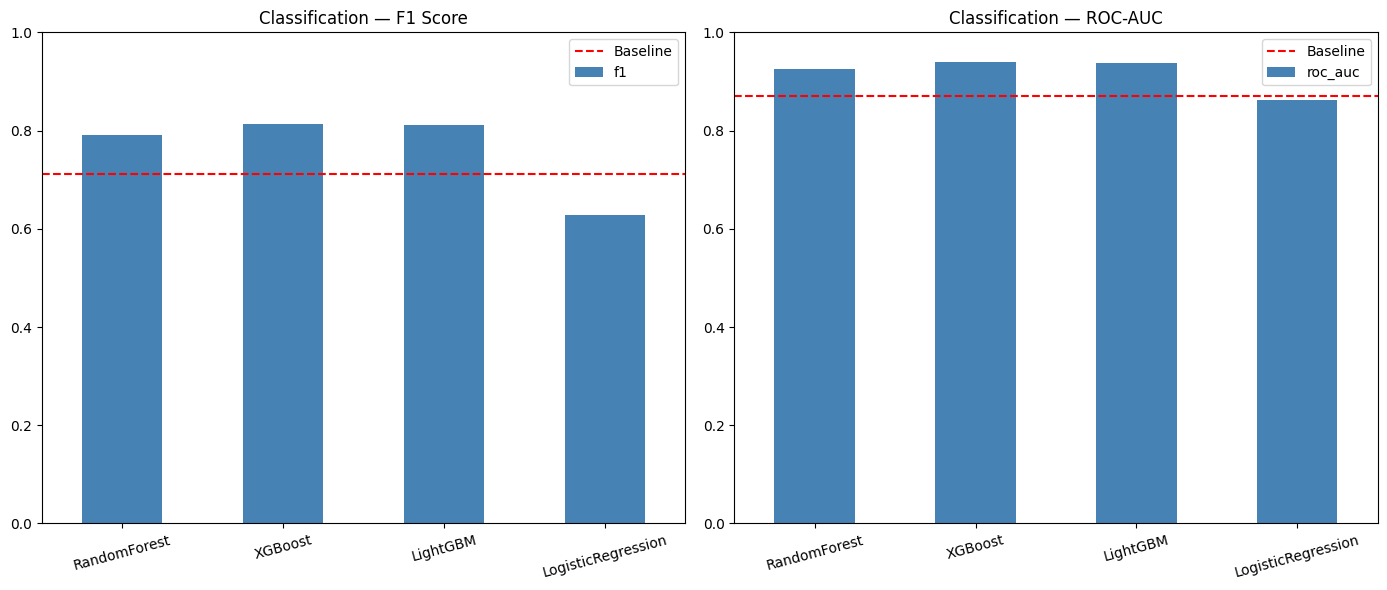

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1 comparison
cls_val_df['f1'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Classification — F1 Score')
axes[0].set_xticklabels(cls_val_df.index, rotation=15)
axes[0].axhline(y=0.7118, color='red', 
                linestyle='--', label='Baseline')
axes[0].legend()
axes[0].set_ylim(0, 1)

# ROC-AUC comparison
cls_val_df['roc_auc'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Classification — ROC-AUC')
axes[1].set_xticklabels(cls_val_df.index, rotation=15)
axes[1].axhline(y=0.8703, color='red',
                linestyle='--', label='Baseline')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

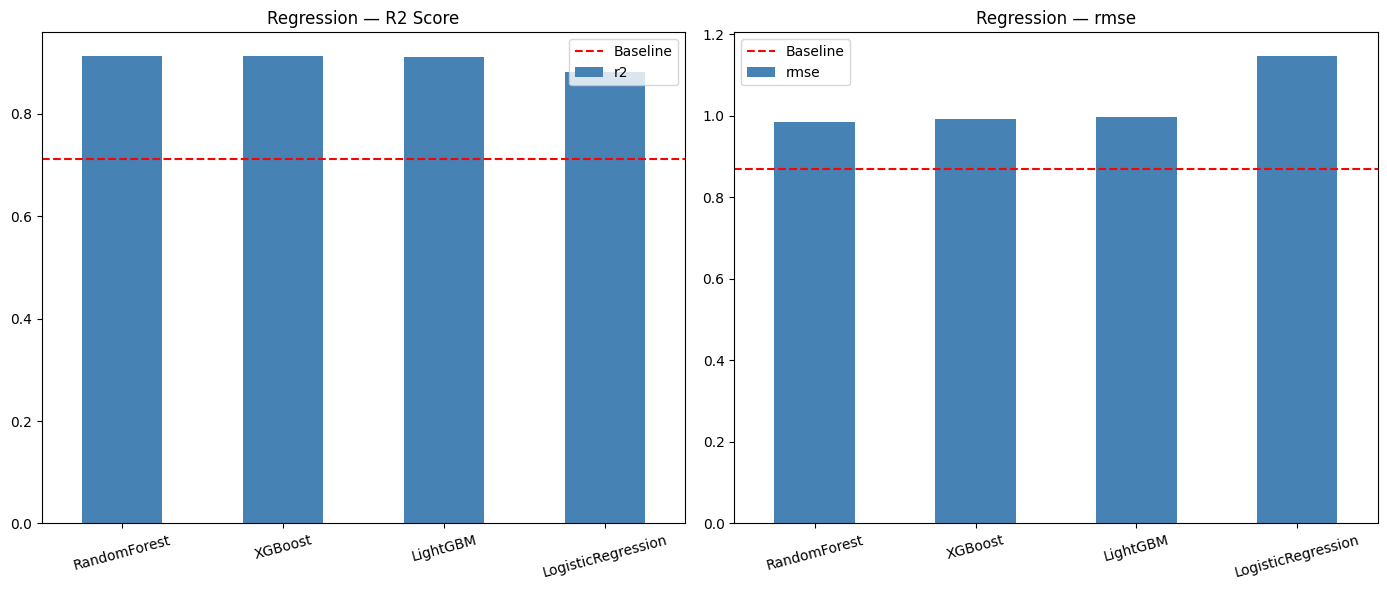

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# r2 comparison
reg_val_df['r2'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Regression — R2 Score')
axes[0].set_xticklabels(cls_val_df.index, rotation=15)
axes[0].axhline(y=0.7118, color='red', 
                linestyle='--', label='Baseline')
axes[0].legend()

# Rmse comparison
reg_val_df['rmse'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Regression — rmse')
axes[1].set_xticklabels(cls_val_df.index, rotation=15)
axes[1].axhline(y=0.8703, color='red',
                linestyle='--', label='Baseline')
axes[1].legend()

plt.tight_layout()
plt.show()

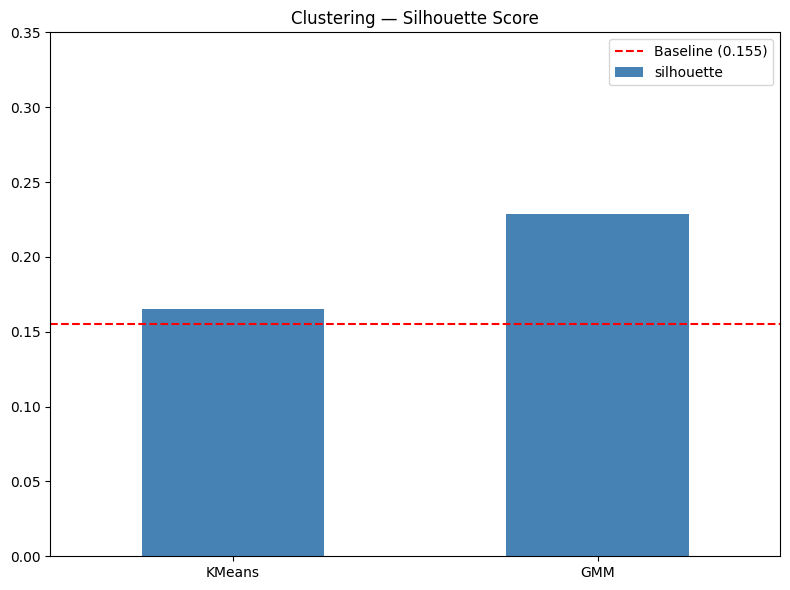

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))

# Silhouette scores
cluster_val_df = pd.DataFrame({
    'KMeans': cluster_val_results['KMeans'],
    'GMM':    cluster_val_results['GMM']
}).T

cluster_val_df['silhouette'].plot(
    kind='bar', ax=ax, color='steelblue')

ax.set_title('Clustering — Silhouette Score')
ax.set_xticklabels(cluster_val_df.index, rotation=0)
ax.axhline(y=0.155, color='red',
           linestyle='--', label='Baseline (0.155)')
ax.legend()
ax.set_ylim(0, 0.35)

plt.tight_layout()
plt.show()

### Step 18: Save All Trained Models

In [57]:
models_path = '../models/Final_Models/'

# Classification
for name, model in final_cls_models.items():
    joblib.dump(model, f'{models_path}cls_{name}.joblib')
    print(f"Saved cls_{name}.joblib")

# Regression
for name, model in final_reg_models.items():
    joblib.dump(model, f'{models_path}reg_{name}.joblib')
    print(f"Saved reg_{name}.joblib")

# Clustering
for name, model in final_cluster_models.items():
    joblib.dump(model, f'{models_path}cluster_{name}.joblib')
    print(f"Saved cluster_{name}.joblib")

print(f"\nAll models saved")
print(f"Total: {len(final_cls_models) + len(final_reg_models) + len(final_cluster_models)} models")

Saved cls_RandomForest.joblib
Saved cls_XGBoost.joblib
Saved cls_LightGBM.joblib
Saved cls_LogisticRegression.joblib
Saved reg_RandomForest.joblib
Saved reg_XGBoost.joblib
Saved reg_LightGBM.joblib
Saved reg_LinearRegression.joblib
Saved cluster_KMeans.joblib
Saved cluster_GMM.joblib

All models saved
Total: 10 models


### Step 19: Save Training Results

In [ ]:
import json

training_results = {
    'classification': {
        'cv_results':  cls_cv_results,
        'val_results': cls_val_results,
        'best_params': cls_best_params
    },
    'regression': {
        'cv_results':  reg_cv_results,
        'val_results': reg_val_results,
        'best_params': reg_best_params
    },
    'clustering': {
        'val_results':  {k: {m: v for m, v in metrics.items() 
                         if m != 'cluster_sizes'} 
                         for k, metrics in cluster_val_results.items()},
        'best_params':  cluster_best_params
    }
}

with open('../models/Project_Parameter_Files/training_results.json', 'w') as f:
    json.dump(training_results, f, indent=4)

print("Training results saved")

Training results saved
Val results CSVs saved


### Step 20: Documents Report

In [63]:
# See report in docs/model_training_report.md